# Titanic — EDA, Cleaning & Data Story

This is Part A of Module 2 for the Zepto Data & AI Platform capstone.

This notebook is where I pull in the raw Titanic data, check the shape and quality of the dataset, fix the missing values, save the cleaned result to `titanic.csv`, and build the story around who survived and why. The next notebook picks up from that cleaned file and does not go back to the raw data again.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load & profile

I load the data with `sns.load_dataset`, and if that fails I fall back to the raw Titanic CSV from the seaborn-data repo. Either way, it is the same dataset that seaborn normally uses, and this is the one place where the raw data is pulled in for the module.


In [2]:
try:
    df = sns.load_dataset("titanic")
except Exception as e:
    print(f"sns.load_dataset failed ({e}); falling back to the raw Titanic CSV from the seaborn-data repo")
    df = pd.read_csv(
        "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    )

# Keep an offline copy as soon as the raw dataset is loaded.
df.to_csv("titanic.csv", index=False)
print("saved raw offline copy:", df.shape)

print(df.shape)
df.head()

saved raw offline copy: (891, 15)
(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe(include="all")


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("shape:", df.shape)


shape: (891, 15)


## 2. Missing values — profile, then handle by rule

For each column with missing values, I follow a simple rule:

- **Less than 5% missing** → drop those rows.
- **Between 5% and 30% missing** → impute them.
- **Too much missingness to trust** → drop the column or treat missing as its own category, depending on what makes sense for that feature.

I do this column by column instead of applying one rule to everything.


In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.to_frame(name="missing_%").round(2)


,missing_%
deck,77.22
age,19.87
embarked,0.22
embark_town,0.22


The missing-value rates are: **`deck` 77.22%**, **`age` 19.87%**, **`embarked` 0.22%**, and **`embark_town` 0.22%**. The same two rows are missing in both `embarked` and `embark_town`.

Here is what I do for each one:

- **`embarked` and `embark_town`**: both are well under 5%, so I drop the two affected rows. That removes passengers 61 and 829, and it does not change the story in any meaningful way.
- **`age`**: this falls in the 5%–30% range, so I impute it. A single overall median would be too blunt because age differs by class and sex, so I use the median age within each (`pclass`, `sex`) group, with the overall median as a fallback for any empty group.
- **`deck`**: this is too sparse to impute reliably, so I drop it entirely. More than three-quarters of the values are missing, and turning it into an "Unknown" bucket would mostly just tell us whether a cabin was recorded at all. It would add noise, and `pclass` and `fare` already carry most of that signal.


In [7]:
# --- embarked / embark_town: drop the 2 rows missing both (< 5% threshold) ---
before = len(df)
df = df.dropna(subset=["embarked", "embark_town"]).reset_index(drop=True)
print(f"dropped {before - len(df)} rows for missing embarked/embark_town -> {len(df)} rows left")

# --- deck: drop the column outright (77% missing, unreliable to impute or bucket) ---
df = df.drop(columns=["deck"])

# --- age: impute with the (pclass, sex) group median (5-30% band) ---
age_before_na = df["age"].isna().sum()
df["age"] = df.groupby(["pclass", "sex"])["age"].transform(lambda s: s.fillna(s.median()))
df["age"] = df["age"].fillna(df["age"].median())  # safety net for any empty group
print(f"imputed {age_before_na} age values using (pclass, sex) group medians")

print(df.isna().sum().sum(), "missing values remaining in the cleaned frame")
print("cleaned shape:", df.shape)


dropped 2 rows for missing embarked/embark_town -> 889 rows left
imputed 177 age values using (pclass, sex) group medians
0 missing values remaining in the cleaned frame
cleaned shape: (889, 14)


No missing values remain. I save the cleaned dataframe as `titanic.csv` in this folder, and the modeling notebook reads that file instead of going back to the raw data. That keeps the cleaning step in one place and makes both notebooks use the same cleaned version.


In [8]:
df.to_csv("titanic.csv", index=False)
print("saved titanic.csv:", df.shape)


saved titanic.csv: (889, 14)


## 3. Looking at age and fare

I start with the two main numeric variables in the dataset: age and fare. I check their distributions, look for obvious outliers, and see how skewed fare is before moving into the survival story.


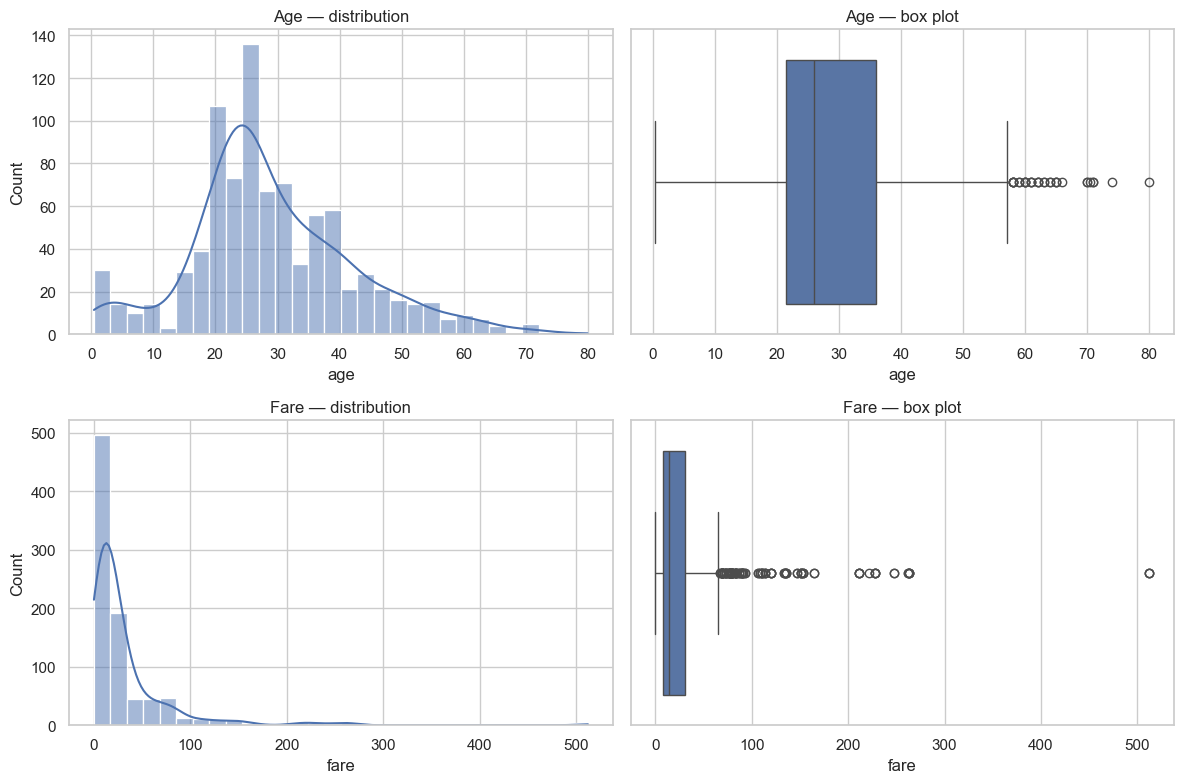

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["age"], bins=30, kde=True, ax=axes[0, 0]).set_title("Age — distribution")
sns.boxplot(x=df["age"], ax=axes[0, 1]).set_title("Age — box plot")
sns.histplot(df["fare"], bins=30, kde=True, ax=axes[1, 0]).set_title("Fare — distribution")
sns.boxplot(x=df["fare"], ax=axes[1, 1]).set_title("Fare — box plot")
plt.tight_layout()
plt.show()


In [10]:
def iqr_outliers(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": lo, "upper_fence": hi,
            "n_outliers": len(out), "pct_outliers": round(len(out) / len(s) * 100, 2)}

age_iqr = iqr_outliers(df["age"])
fare_iqr = iqr_outliers(df["fare"])
pd.DataFrame({"age": age_iqr, "fare": fare_iqr}).round(3)


,age,fare
Q1,21.50,7.896
Q3,36.00,31.000
IQR,14.50,23.104
lower_fence,-0.25,-26.760
upper_fence,57.75,65.656
n_outliers,32.00,114.000
pct_outliers,3.60,12.820


In [11]:
fare_mean, fare_median, fare_mode = df["fare"].mean(), df["fare"].median(), df["fare"].mode().iloc[0]
print(f"fare mean={fare_mean:.2f}  median={fare_median:.2f}  mode={fare_mode:.2f}")


fare mean=32.10  median=14.45  mode=8.05


**Age** is mostly concentrated in the younger-to-middle range, with a few older passengers pushing the upper end up. The IQR fence lands around 57.75, which means only a small group of older passengers show up as outliers. That makes sense because the age data was imputed in a grouped way, which keeps the distribution fairly stable instead of creating a bunch of extreme values.

**Fare** is much more skewed. The IQR fence is roughly [-26.8, 65.7], and there are 114 outliers on the high end. That is a big clue that the ticket price distribution is dominated by a small number of expensive first-class fares, not by random data-entry mistakes.

The fare pattern is classic right-skew: the mean is higher than the median, and the median is higher than the mode. In plain terms, most passengers paid fairly modest amounts, while a handful of very expensive tickets pulled the average upward.

## 4. Looking at survival by group

The next step is to check whether survival changes by sex, class, and the combination of the two. I also look at how the key variables relate to each other so I can separate real signals from patterns that are just caused by other factors.


In [12]:
# survival rate by sex, via boolean masking
female_mask = df["sex"] == "female"
male_mask = df["sex"] == "male"

survival_by_sex = pd.Series({
    "female": df.loc[female_mask, "survived"].mean(),
    "male": df.loc[male_mask, "survived"].mean(),
})
survival_by_sex.round(4).to_frame("survival_rate")


,survival_rate
female,0.7404
male,0.1889


In [13]:
# survival rate by pclass, via boolean masking
survival_by_pclass = pd.Series({
    p: df.loc[df["pclass"] == p, "survived"].mean() for p in sorted(df["pclass"].unique())
})
survival_by_pclass.round(4).to_frame("survival_rate")


,survival_rate
1,0.6262
2,0.4728
3,0.2424


In [14]:
# survival rate by sex AND pclass combined, via chained boolean masks (&)
rows = []
for sex_val, sex_mask in [("female", female_mask), ("male", male_mask)]:
    for p in sorted(df["pclass"].unique()):
        mask = sex_mask & (df["pclass"] == p)
        rows.append({"sex": sex_val, "pclass": p,
                     "n": mask.sum(), "survival_rate": df.loc[mask, "survived"].mean()})
survival_by_sex_pclass = pd.DataFrame(rows)
survival_by_sex_pclass["survival_rate"] = survival_by_sex_pclass["survival_rate"].round(4)
survival_by_sex_pclass


,sex,pclass,n,survival_rate
0,female,1,92,0.9674
1,female,2,76,0.9211
2,female,3,144,0.5000
3,male,1,122,0.3689
4,male,2,108,0.1574
5,male,3,347,0.1354


- **By sex**: women survived at **74.0%**, while men survived at **18.9%**. That gap is huge and matches the idea that women and children were prioritized.
- **By class**: survival fell steadily from **62.6%** in first class to **47.3%** in second class and **24.2%** in third class.
- **By sex and class together**: first- and second-class women had survival rates of **96.7%** and **92.1%**. Third-class women still did better than men, but their survival rate was only **50.0%**. Men did much worse overall, with **36.9%** in first class, **15.7%** in second, and **13.5%** in third.

So sex is the biggest driver, but class still matters a lot within each sex. The difference between first-class and third-class women is enormous.

In [15]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]  # adult_male/alone excluded: derived/redundant flags
corr = df[corr_cols].corr()
corr.round(3)


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.064,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.411,0.082,0.017,-0.548
age,-0.064,-0.411,1.000,-0.249,-0.175,0.120
sibsp,-0.034,0.082,-0.249,1.000,0.415,0.161
parch,0.083,0.017,-0.175,0.415,1.000,0.218
fare,0.255,-0.548,0.120,0.161,0.218,1.000


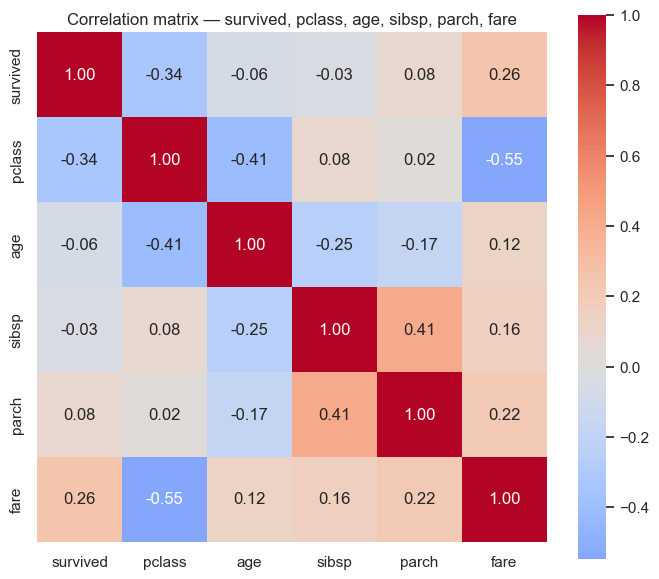

In [16]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix — survived, pclass, age, sibsp, parch, fare")
plt.tight_layout()
plt.show()


In [17]:
# rank all off-diagonal pairs by |corr| to find the two strongest relationships
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        pairs.append((corr_cols[i], corr_cols[j], corr.iloc[i, j]))
pairs.sort(key=lambda t: -abs(t[2]))
pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"]).round(3)


,feature_1,feature_2,corr
0,pclass,fare,-0.548
1,sibsp,parch,0.415
2,pclass,age,-0.411
3,survived,pclass,-0.336
4,survived,fare,0.255
5,age,sibsp,-0.249
6,parch,fare,0.218
7,age,parch,-0.175
8,sibsp,fare,0.161
9,age,fare,0.120


The two strongest relationships in the matrix are:

1. **`pclass` vs `fare`: -0.55** — this is the clearest pattern in the data. Lower class numbers mean higher fares, so the negative sign makes sense. It also helps explain why class is linked to survival: fare and class are basically two ways of describing the same underlying story of ticket quality and social position.
2. **`sibsp` vs `parch`: +0.42** — passengers who traveled with more siblings or spouses also tended to travel with more parents or children. That is really a family-travel signal rather than two separate behaviors.

The strongest correlation involving survival is with `pclass`, which lines up with what we saw earlier. The bigger relationships in the matrix are structural ones, like ticket price and family size, rather than direct survival drivers. 

## 5. The bigger picture — who survived, and why

The charts point to one story: sex mattered most, class mattered a lot, and age and family size played a smaller role. Taken together, the patterns suggest that survival was shaped by both social positioning and the evacuation rules on the ship.


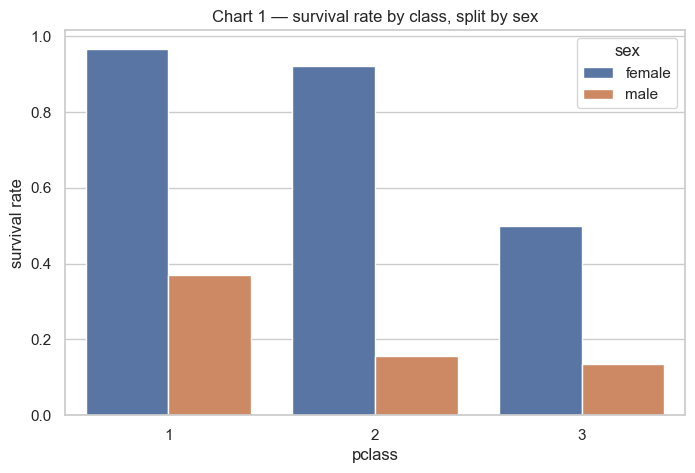

In [18]:
# Chart 1 - grouped bar: survival rate by class, split by sex
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.ylabel("survival rate")
plt.title("Chart 1 — survival rate by class, split by sex")
plt.show()


Women in first and second class were almost always safe, while women in third class had a much worse outcome. Men were far less likely to survive across every class, and class did not help them nearly as much. In other words, the evacuation rule clearly favored women, but it was still shaped by class.


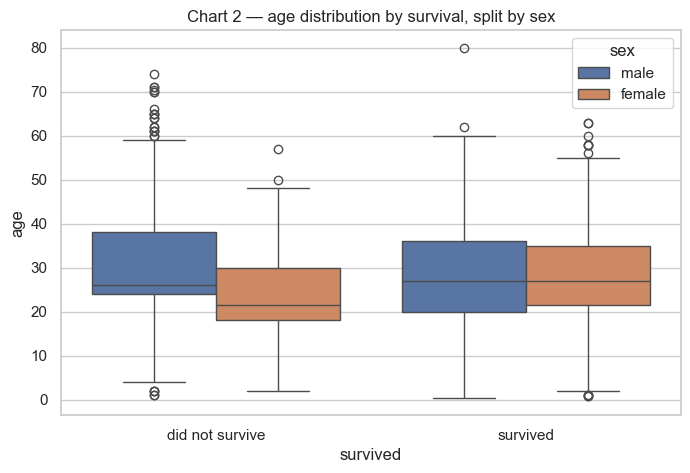

In [19]:
# Chart 2 - box plot: age distribution by survival outcome, split by sex
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="age", hue="sex")
plt.xticks([0, 1], ["did not survive", "survived"])
plt.title("Chart 2 — age distribution by survival, split by sex")
plt.show()


The age distributions are not wildly different by survival outcome, and the median age for survivors is only a little higher than for non-survivors. That suggests age alone is not the main story here. The bigger pattern is still the strong gap between men and women, with age acting more like a secondary effect than the main driver.


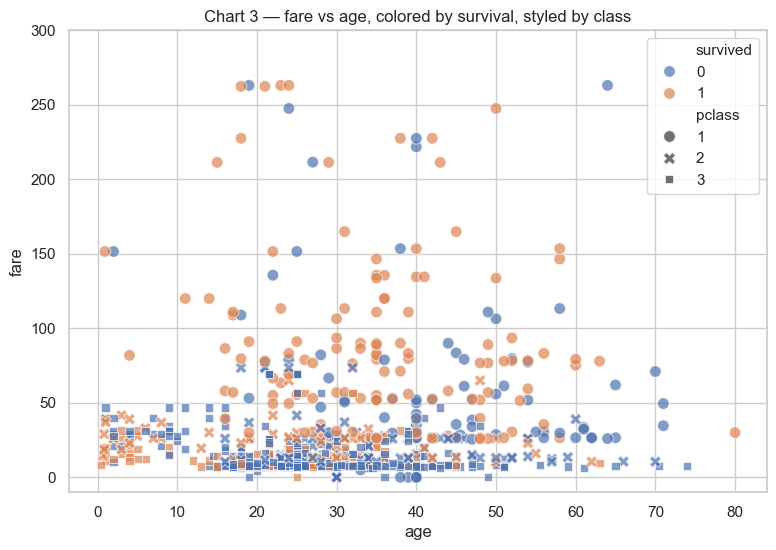

In [20]:
# Chart 3 - scatter: fare vs age, colored by survival, sized/faceted by class
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", style="pclass", alpha=0.7, s=70)
plt.title("Chart 3 — fare vs age, colored by survival, styled by class")
plt.ylim(-10, 300)  # a few extreme fares compressed for readability
plt.show()


The survivors are mostly clustered at higher fares, while the lower-fare passengers are dominated by non-survivors. This fits the broader pattern that people in higher classes had better odds, regardless of age. A wealthier passenger was simply in a much stronger position than someone traveling in the lower classes.


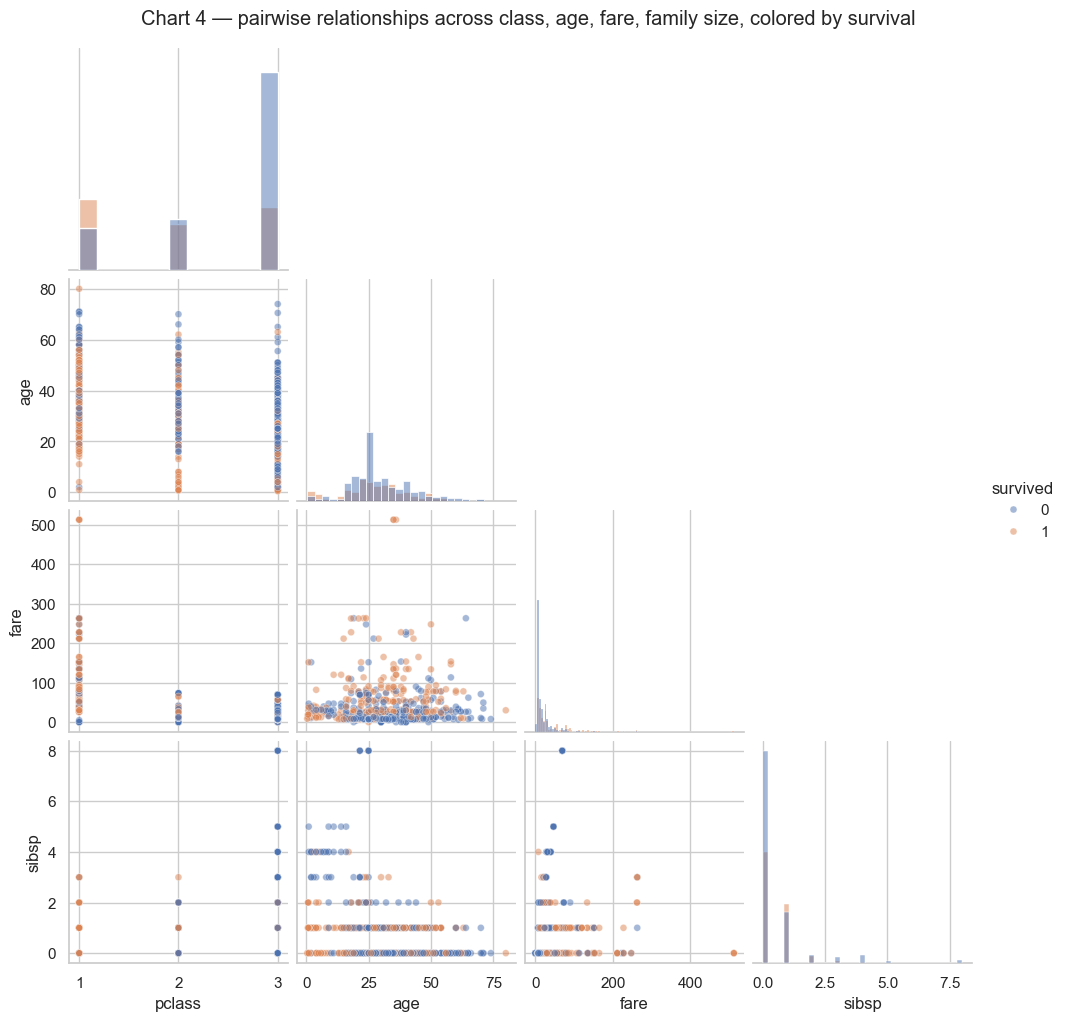

In [21]:
# Chart 4 - pairplot across the core numeric story variables, colored by survival
story_cols = ["survived", "pclass", "age", "fare", "sibsp"]
g = sns.pairplot(df[story_cols], hue="survived", corner=True, diag_kind="hist",
                  plot_kws={"alpha": 0.5, "s": 25})
g.fig.suptitle("Chart 4 — pairwise relationships across class, age, fare, family size, colored by survival", y=1.02)
plt.show()


The pairplot pulls the story together: survivors are concentrated in the lower class and higher fare range, while non-survivors are more common among cheaper tickets. Family size is there, but it is a weaker signal compared with sex and class.


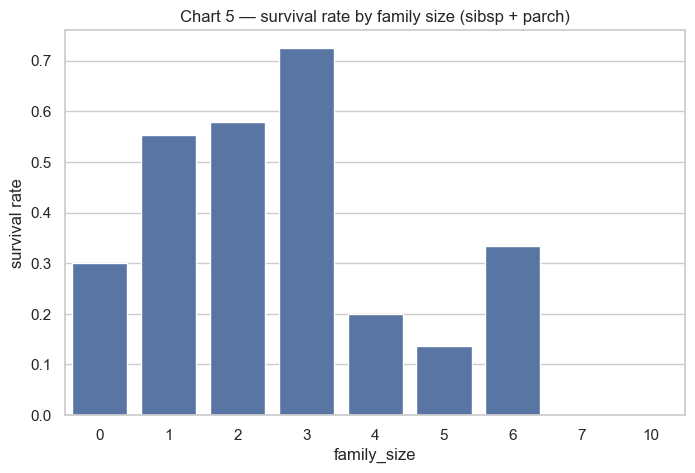

In [22]:
# Chart 5 (bonus) - family size derived quickly for one more angle on the story
df["family_size"] = df["sibsp"] + df["parch"]
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="family_size", y="survived", errorbar=None)
plt.ylabel("survival rate")
plt.title("Chart 5 — survival rate by family size (sibsp + parch)")
plt.show()


Traveling alone is linked to the lowest survival rate, while small families do a bit better. Very large families do worse again, which likely reflects the fact that many lower-income passengers were traveling in third class and had a harder time getting into lifeboats. Family size matters, but it is still secondary to sex and class.


## 6. Quick standardization check

This is only a sanity check and does not feed into the modeling pipeline. The next notebook will fit its own scaler on the training data only, which is the correct way to avoid leakage. Here, I just want to confirm that z-scoring on `age` and `fare` behaves as expected.


In [23]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df[["age", "fare"]])
scaled_df = pd.DataFrame(scaled, columns=["age_z", "fare_z"])

comparison = pd.DataFrame({
    "age_before_mean": [df["age"].mean()], "age_before_std": [df["age"].std()],
    "age_after_mean": [scaled_df["age_z"].mean()], "age_after_std": [scaled_df["age_z"].std(ddof=0)],
    "fare_before_mean": [df["fare"].mean()], "fare_before_std": [df["fare"].std()],
    "fare_after_mean": [scaled_df["fare_z"].mean()], "fare_after_std": [scaled_df["fare_z"].std(ddof=0)],
}).T
comparison.columns = ["value"]
comparison.round(4)


,value
age_before_mean,29.0654
age_before_std,13.2702
age_after_mean,0.0000
age_after_std,1.0000
fare_before_mean,32.0967
fare_before_std,49.6975
fare_after_mean,0.0000
fare_after_std,1.0000


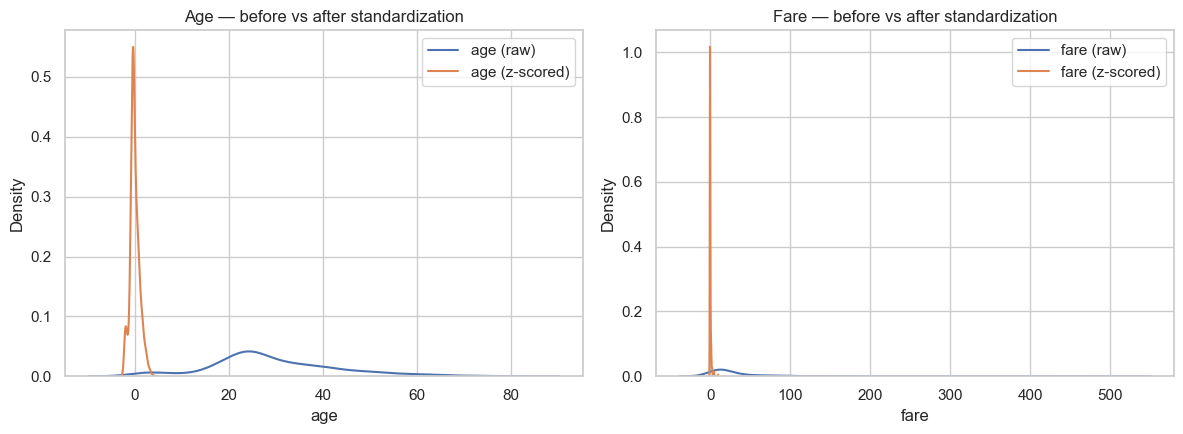

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.kdeplot(df["age"], ax=axes[0], label="age (raw)")
sns.kdeplot(scaled_df["age_z"], ax=axes[0], label="age (z-scored)")
axes[0].set_title("Age — before vs after standardization")
axes[0].legend()

sns.kdeplot(df["fare"], ax=axes[1], label="fare (raw)")
sns.kdeplot(scaled_df["fare_z"], ax=axes[1], label="fare (z-scored)")
axes[1].set_title("Fare — before vs after standardization")
axes[1].legend()
plt.tight_layout()
plt.show()


After z-scoring, both `age_z` and `fare_z` have mean near 0 and standard deviation near 1, which is what we would expect from `StandardScaler`. The overall distributions stay the same shape; the transformation just shifts and rescales them. The skew in `fare` is still visible, it is just centered at zero.


## Summary

The cleaned dataset has **889 rows and 14 columns**, with the `deck` column removed and no missing values left. The survival split is **61.75% did not survive** and **38.25% survived**, which is a mild imbalance and something the modeling notebook handles explicitly with stratified splitting and a comparison of class weighting versus SMOTE.
